In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Coordenadas homogéneas en 2D

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definir puntos 2D (triángulo)
points_2d = np.array([
    [0, 0],
    [2, 0],
    [1, 2]
])

# Convertir a coordenadas homogéneas (x, y, 1)
ones = np.ones((points_2d.shape[0], 1))
points_h = np.hstack((points_2d, ones))

points_h

array([[0., 0., 1.],
       [2., 0., 1.],
       [1., 2., 1.]])

In [3]:
def translation_matrix(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])


def rotation_matrix(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])


def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])


def reflection_x():
    return np.array([
        [1, 0, 0],
        [0, -1, 0],
        [0, 0, 1]
    ])

In [4]:
def apply_transformation(points, T):
    return (T @ points.T).T

In [5]:
# Crear transformaciones
T = translation_matrix(3, 1)
R = rotation_matrix(np.pi / 4)  # 45 grados
S = scaling_matrix(1.5, 0.5)
Ref = reflection_x()

# Aplicar
translated = apply_transformation(points_h, T)
rotated = apply_transformation(points_h, R)
scaled = apply_transformation(points_h, S)
reflected = apply_transformation(points_h, Ref)

In [6]:
def plot_shape(original, transformed, title):
    plt.figure()
    
    # Cerrar figura repitiendo el primer punto
    original_closed = np.vstack([original, original[0]])
    transformed_closed = np.vstack([transformed, transformed[0]])

    plt.plot(original_closed[:,0], original_closed[:,1], 'bo-', label='Original')
    plt.plot(transformed_closed[:,0], transformed_closed[:,1], 'ro-', label='Transformado')

    plt.axhline(0)
    plt.axvline(0)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

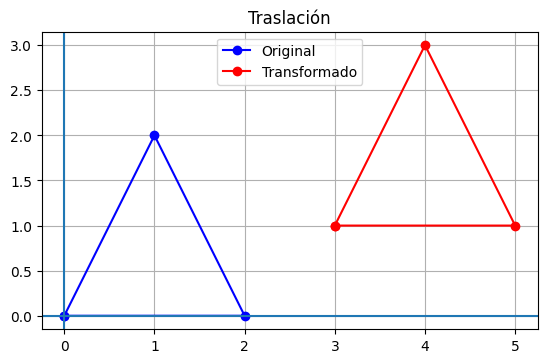

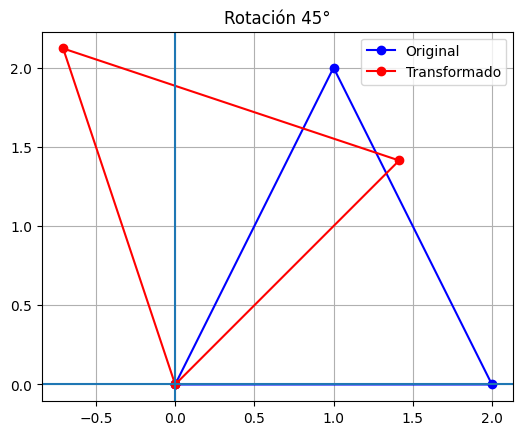

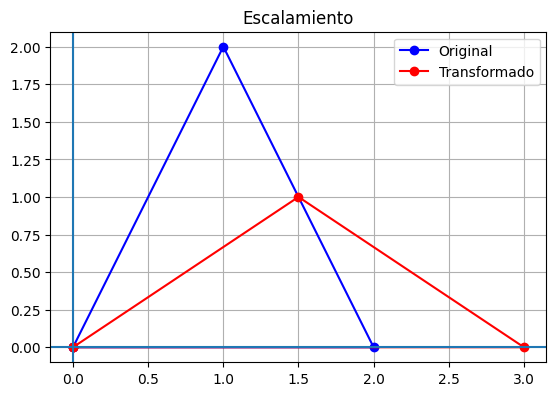

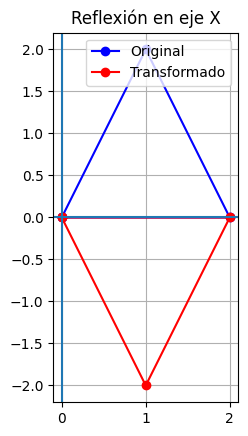

In [7]:
plot_shape(points_h[:, :2], translated[:, :2], "Traslación")
plot_shape(points_h[:, :2], rotated[:, :2], "Rotación 45°")
plot_shape(points_h[:, :2], scaled[:, :2], "Escalamiento")
plot_shape(points_h[:, :2], reflected[:, :2], "Reflexión en eje X")

# Composición de transformaciones

In [8]:
theta = np.pi / 4  # 45 grados

R = rotation_matrix(theta)
T = translation_matrix(3, 1)

print("Matriz de Rotación:\n", R)
print("\nMatriz de Traslación:\n", T)

Matriz de Rotación:
 [[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]

Matriz de Traslación:
 [[1 0 3]
 [0 1 1]
 [0 0 1]]


In [9]:
# Rotar y luego trasladar
TR = T @ R

# Trasladar y luego rotar
RT = R @ T

print("T @ R:\n", TR)
print("\nR @ T:\n", RT)

T @ R:
 [[ 0.70710678 -0.70710678  3.        ]
 [ 0.70710678  0.70710678  1.        ]
 [ 0.          0.          1.        ]]

R @ T:
 [[ 0.70710678 -0.70710678  1.41421356]
 [ 0.70710678  0.70710678  2.82842712]
 [ 0.          0.          1.        ]]


In [10]:
print("¿Son iguales?", np.allclose(TR, RT))

¿Son iguales? False


In [11]:
# Aplicar composiciones
result_TR = apply_transformation(points_h, TR)
result_RT = apply_transformation(points_h, RT)

In [12]:
# Aplicación secuencial: rotar y luego trasladar
sequential = apply_transformation(
    apply_transformation(points_h, R),
    T
)

print("¿Composición equivale a secuencial?",
      np.allclose(result_TR, sequential))

¿Composición equivale a secuencial? True


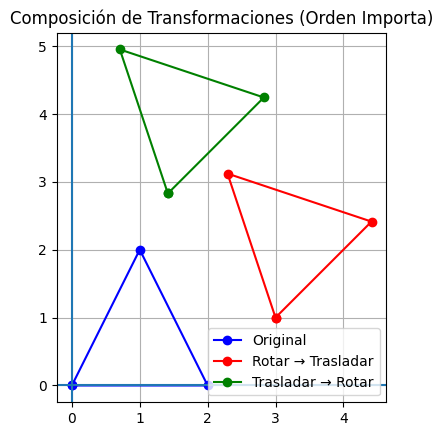

In [13]:
plt.figure()

original_closed = np.vstack([points_h[:, :2], points_h[0, :2]])
TR_closed = np.vstack([result_TR[:, :2], result_TR[0, :2]])
RT_closed = np.vstack([result_RT[:, :2], result_RT[0, :2]])

plt.plot(original_closed[:,0], original_closed[:,1], 'bo-', label='Original')
plt.plot(TR_closed[:,0], TR_closed[:,1], 'ro-', label='Rotar → Trasladar')
plt.plot(RT_closed[:,0], RT_closed[:,1], 'go-', label='Trasladar → Rotar')

plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Composición de Transformaciones (Orden Importa)")
plt.grid(True)
plt.show()

# Coordenadas homogéneas en 3D

In [14]:
from mpl_toolkits.mplot3d import Axes3D

In [15]:
# Definir vértices de un cubo
cube_points = np.array([
    [-1, -1, -1],
    [ 1, -1, -1],
    [ 1,  1, -1],
    [-1,  1, -1],
    [-1, -1,  1],
    [ 1, -1,  1],
    [ 1,  1,  1],
    [-1,  1,  1]
])

# Convertir a coordenadas homogéneas (x, y, z, 1)
ones = np.ones((cube_points.shape[0], 1))
cube_h = np.hstack((cube_points, ones))

cube_h

array([[-1., -1., -1.,  1.],
       [ 1., -1., -1.,  1.],
       [ 1.,  1., -1.,  1.],
       [-1.,  1., -1.,  1.],
       [-1., -1.,  1.,  1.],
       [ 1., -1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.],
       [-1.,  1.,  1.,  1.]])

## Matrices de transformación

In [17]:
def translation_matrix_3d(tx, ty, tz):
    return np.array([
        [1, 0, 0, tx],
        [0, 1, 0, ty],
        [0, 0, 1, tz],
        [0, 0, 0, 1]
    ])

def scaling_matrix_3d(sx, sy, sz):
    return np.array([
        [sx, 0, 0, 0],
        [0, sy, 0, 0],
        [0, 0, sz, 0],
        [0, 0, 0, 1]
    ])

def rotation_x(theta):
    return np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta), -np.sin(theta), 0],
        [0, np.sin(theta),  np.cos(theta), 0],
        [0, 0, 0, 1]
    ])

def rotation_y(theta):
    return np.array([
        [ np.cos(theta), 0, np.sin(theta), 0],
        [0, 1, 0, 0],
        [-np.sin(theta), 0, np.cos(theta), 0],
        [0, 0, 0, 1]
    ])

def rotation_z(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0, 0],
        [np.sin(theta),  np.cos(theta), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

In [18]:
def apply_transformation_3d(points, T):
    return (T @ points.T).T

In [19]:
theta = np.pi / 6

Rx = rotation_x(theta)
Ry = rotation_y(theta)
S = scaling_matrix_3d(1.5, 0.5, 1)
T = translation_matrix_3d(3, 2, 1)

T_total = T @ Ry @ Rx @ S

cube_transformed = apply_transformation_3d(cube_h, T_total)

In [20]:
edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]

In [21]:
def plot_cube(original, transformed):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Cubo original
    for edge in edges:
        ax.plot(
            [original[edge[0],0], original[edge[1],0]],
            [original[edge[0],1], original[edge[1],1]],
            [original[edge[0],2], original[edge[1],2]],
            'b'
        )

    # Cubo transformado
    for edge in edges:
        ax.plot(
            [transformed[edge[0],0], transformed[edge[1],0]],
            [transformed[edge[0],1], transformed[edge[1],1]],
            [transformed[edge[0],2], transformed[edge[1],2]],
            'r'
        )

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_box_aspect([1,1,1])
    plt.title("Cubo 3D - Original (Azul) vs Transformado (Rojo)")
    plt.show()

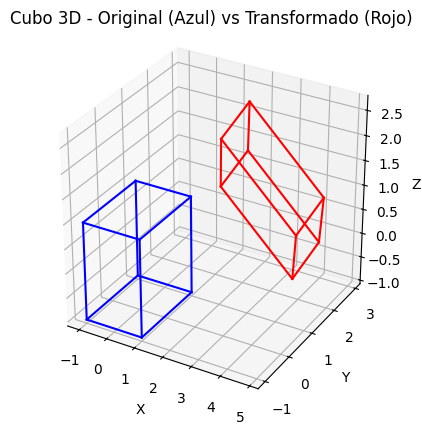

In [22]:
plot_cube(cube_h[:, :3], cube_transformed[:, :3])

# Cambios de base

In [23]:
## El marco A será el marco unitario

## El marco B se obtiene al rotar el marco A 45° alrededor del eje Z y luego trasladarlo a (3, 2, 1)
theta = np.pi / 4

R = rotation_z(theta)
T = translation_matrix_3d(3, 2, 1)

# Transformación del marco B respecto al mundo A
T_A_B = T @ R

T_A_B

array([[ 0.70710678, -0.70710678,  0.        ,  3.        ],
       [ 0.70710678,  0.70710678,  0.        ,  2.        ],
       [ 0.        ,  0.        ,  1.        ,  1.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [24]:
# Punto en sistema B
p_B = np.array([1, 0, 0, 1])

# Convertir a coordenadas del mundo
p_A = T_A_B @ p_B

print("Punto en B:", p_B)
print("Mismo punto en A:", p_A)

Punto en B: [1 0 0 1]
Mismo punto en A: [3.70710678 2.70710678 1.         1.        ]


In [26]:
# Cambio inverso
T_B_A = np.linalg.inv(T_A_B)

p_B_recovered = T_B_A @ p_A

print("Recuperado:", p_B_recovered)

Recuperado: [1. 0. 0. 1.]


In [27]:
def plot_frame(ax, T, name, length=1):

    origin = T @ np.array([0,0,0,1])
    x_axis = T @ np.array([length,0,0,1])
    y_axis = T @ np.array([0,length,0,1])
    z_axis = T @ np.array([0,0,length,1])

    ax.quiver(origin[0], origin[1], origin[2],
              x_axis[0]-origin[0],
              x_axis[1]-origin[1],
              x_axis[2]-origin[2],
              color='r')

    ax.quiver(origin[0], origin[1], origin[2],
              y_axis[0]-origin[0],
              y_axis[1]-origin[1],
              y_axis[2]-origin[2],
              color='g')

    ax.quiver(origin[0], origin[1], origin[2],
              z_axis[0]-origin[0],
              z_axis[1]-origin[1],
              z_axis[2]-origin[2],
              color='b')

    ax.text(origin[0], origin[1], origin[2], name)

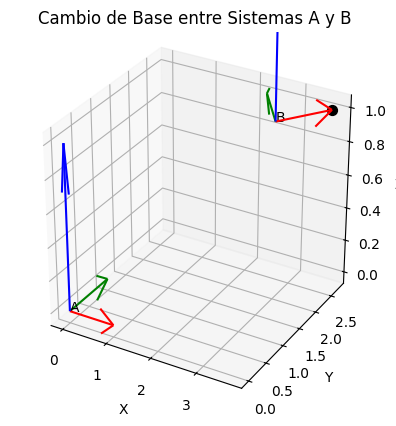

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Marco mundo (identidad)
plot_frame(ax, np.eye(4), "A")

# Marco B
plot_frame(ax, T_A_B, "B")

# Dibujar punto
ax.scatter(p_A[0], p_A[1], p_A[2], color='k', s=50)

ax.set_box_aspect([1,1,1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title("Cambio de Base entre Sistemas A y B")
plt.show()

## Cadena cinemática

In [29]:
theta1 = np.pi / 6
theta2 = np.pi / 4

T_A_B = rotation_z(theta1) @ translation_matrix_3d(2,0,0)
T_B_C = rotation_z(theta2) @ translation_matrix_3d(2,0,0)

T_A_C = T_A_B @ T_B_C

# Posición del efector final
end_effector = T_A_C @ np.array([0,0,0,1])

end_effector

array([2.2496889 , 2.93185165, 0.        , 1.        ])

# Transformaciones inversas

In [30]:
theta = np.pi / 6

R = rotation_z(theta)
T = translation_matrix_3d(3, 2, 1)

# Transformación compuesta
T_total = T @ R

T_total

array([[ 0.8660254, -0.5      ,  0.       ,  3.       ],
       [ 0.5      ,  0.8660254,  0.       ,  2.       ],
       [ 0.       ,  0.       ,  1.       ,  1.       ],
       [ 0.       ,  0.       ,  0.       ,  1.       ]])

In [31]:
T_inv = np.linalg.inv(T_total)

T_inv

array([[ 0.8660254 ,  0.5       ,  0.        , -3.59807621],
       [-0.5       ,  0.8660254 ,  0.        , -0.23205081],
       [ 0.        ,  0.        ,  1.        , -1.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [32]:
identity_check = T_total @ T_inv

print(identity_check)
print("\n¿Es identidad?", np.allclose(identity_check, np.eye(4)))

[[ 1.00000000e+00 -7.43708407e-18  0.00000000e+00  0.00000000e+00]
 [ 4.06369831e-17  1.00000000e+00  0.00000000e+00 -4.44089210e-16]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

¿Es identidad? True


In [33]:
p = np.array([1, 2, 0, 1])

# Aplicar transformación
p_transformed = T_total @ p

# Aplicar inversa
p_recovered = T_inv @ p_transformed

print("Original:", p)
print("Transformado:", p_transformed)
print("Recuperado:", p_recovered)

Original: [1 2 0 1]
Transformado: [2.8660254  4.23205081 1.         1.        ]
Recuperado: [1. 2. 0. 1.]


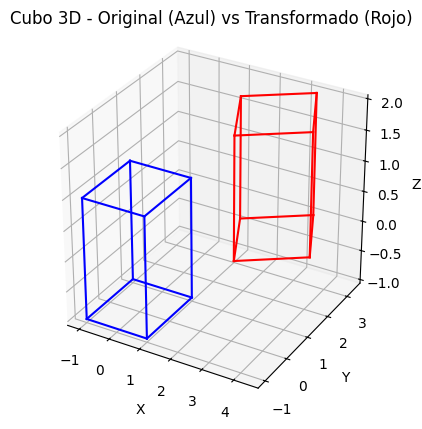

In [34]:
cube_transformed = apply_transformation_3d(cube_h, T_total)
cube_recovered = apply_transformation_3d(cube_transformed, T_inv)

plot_cube(cube_h[:, :3], cube_transformed[:, :3])

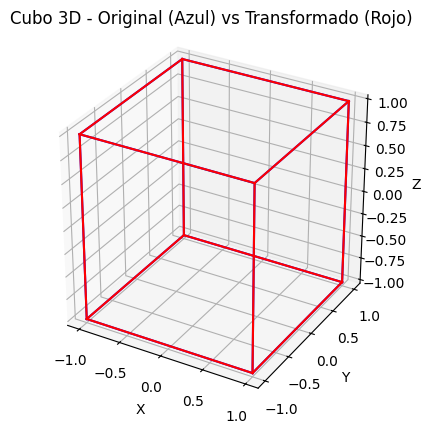

In [35]:
plot_cube(cube_h[:, :3], cube_recovered[:, :3])

# Aplicación en robótica

In [41]:
def planar_link(theta, L):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0, L*np.cos(theta)],
        [np.sin(theta),  np.cos(theta), 0, L*np.sin(theta)],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

In [42]:
L1 = 3
L2 = 2

theta1 = np.pi / 6
theta2 = np.pi / 4

T_A_B = planar_link(theta1, L1)
T_B_C = planar_link(theta2, L2)

T_A_C = T_A_B @ T_B_C

In [43]:
# Transformación Base -> Joint1
T_A_B = rotation_z(theta1) @ translation_matrix_3d(L1, 0, 0)

# Transformación Joint1 -> Joint2
T_B_C = rotation_z(theta2) @ translation_matrix_3d(L2, 0, 0)

# Transformación Base -> End Effector
T_A_C = T_A_B @ T_B_C

In [44]:
O_A = np.array([0,0,0,1])
O_B = T_A_B @ np.array([0,0,0,1])
O_C = T_A_C @ np.array([0,0,0,1])

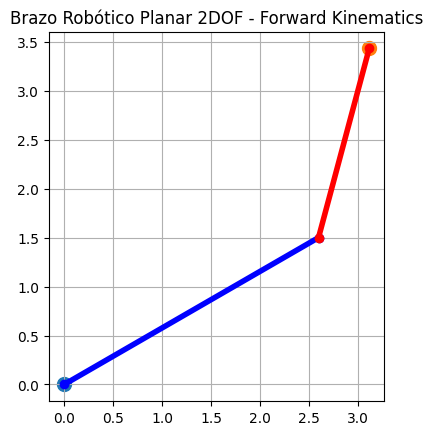

In [45]:
plt.figure()

plt.plot([0, O_B[0]], [0, O_B[1]], 'bo-', linewidth=4)
plt.plot([O_B[0], O_C[0]], [O_B[1], O_C[1]], 'ro-', linewidth=4)

plt.scatter(0,0, s=100)
plt.scatter(O_C[0], O_C[1], s=100)

plt.gca().set_aspect('equal')
plt.grid(True)
plt.title("Brazo Robótico Planar 2DOF - Forward Kinematics")
plt.show()